<a href="https://colab.research.google.com/github/leejunho12316/HonGongMachine/blob/main/Markdown%EC%9C%BC%EB%A1%9C_Image_%EC%B6%9C%EB%A0%A5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# 문서 제목

여기는 첫 번째 문단입니다.
텍스트를 여러 줄 작성할 수 있습니다.

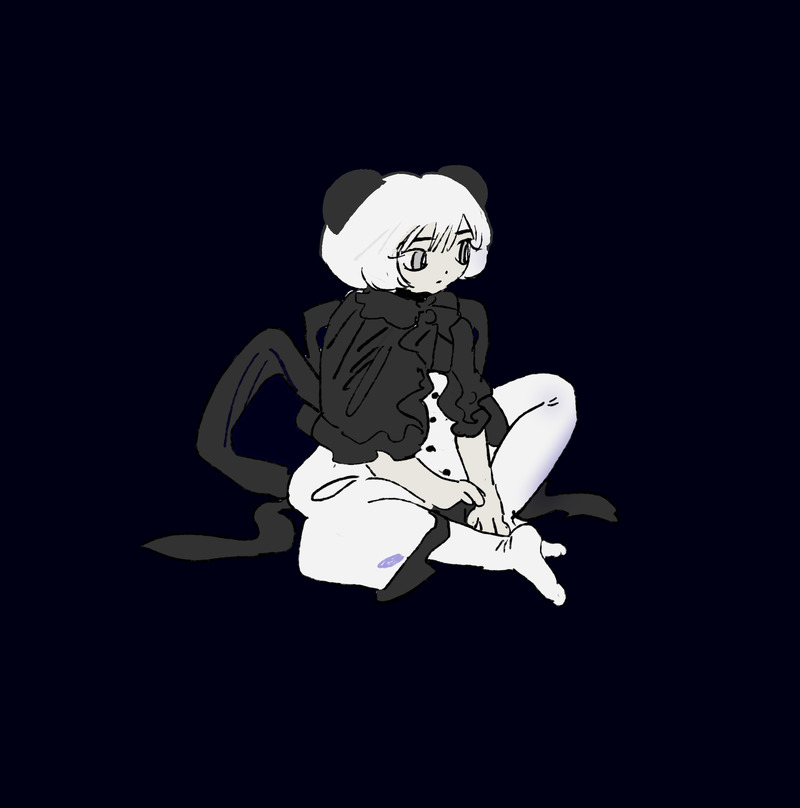

이미지가 중간에 있다면 실제 중간에 있는 이미지를 답변에 삽입해줄 것입니다.


In [38]:
import re
import base64
from IPython.display import display, Markdown

def display_md_w_images(md_text,width):

  #3. Match 객체를 받아 처리 진행 후 str 반환
  def replacer(match):
    #group(0) : 전체, group(1) ~ : 괄호로 지정한 그룹
    img_path = match.group(1)

    #확장자, base64 추출
    with open(img_path, "rb") as f:
        ext = img_path.split('.')[-1].lower()
        mime_type = "image/jpeg" if ext in ["jpg", "jpeg"] else "image/png"
        b64_img = base64.b64encode(f.read()).decode('utf-8')

    #Markdown img 표현 형식 return
    return f'<img src="data:{mime_type};base64,{b64_img}" width="{width}">'

  #1. re 객체 선언
  pattern = re.compile(r'<img\s+src="([^"]+)"[^>]*>')

  #2. sub를 통해 찾은 결과물인 Match 객체를 함수에 전달.
  subbed_text = pattern.sub(replacer, md_text)

  return subbed_text



# 입력 마크다운 문자열
md_input = """
# 문서 제목

여기는 첫 번째 문단입니다.
텍스트를 여러 줄 작성할 수 있습니다.

<img src="/content/11.png">

이미지가 중간에 있다면 실제 중간에 있는 이미지를 답변에 삽입해줄 것입니다.
"""

# 이미지 너비를 50px로 지정
Markdown(display_md_w_images(md_input, width=400))

'*'

In [8]:
import re
import base64
from IPython.display import display, Markdown

def display_markdown_with_images(md_text, width):
    """이미지 태그를 찾아 base64로 변환하고 지정된 너비로 조절"""
    pattern = re.compile(r'<img\s+src="([^"]+)"[^>]*>')

    def replace_match(match):
        img_path = match.group(1)

        try:
            # Colab 경로 처리
            if img_path.startswith('/content/'):
                full_path = img_path
            else:
                full_path = f'/content/{img_path}'

            with open(full_path, "rb") as f:
                ext = img_path.split('.')[-1].lower()
                mime_type = "image/jpeg" if ext in ["jpg", "jpeg"] else "image/png"
                b64_img = base64.b64encode(f.read()).decode('utf-8')

            # 이미지 태그 생성 (width 속성 직접 지정)
            return f'<img src="data:{mime_type};base64,{b64_img}" width="{width}">'

        except FileNotFoundError:
            print(f"파일을 찾을 수 없습니다: {full_path}")
            return match.group(0)

    # 모든 이미지 태그 교체
    result = pattern.sub(replace_match, md_text)

    display(Markdown(result))



# 문서 제목

여기는 첫 번째 문단입니다.
텍스트를 여러 줄 작성할 수 있습니다.

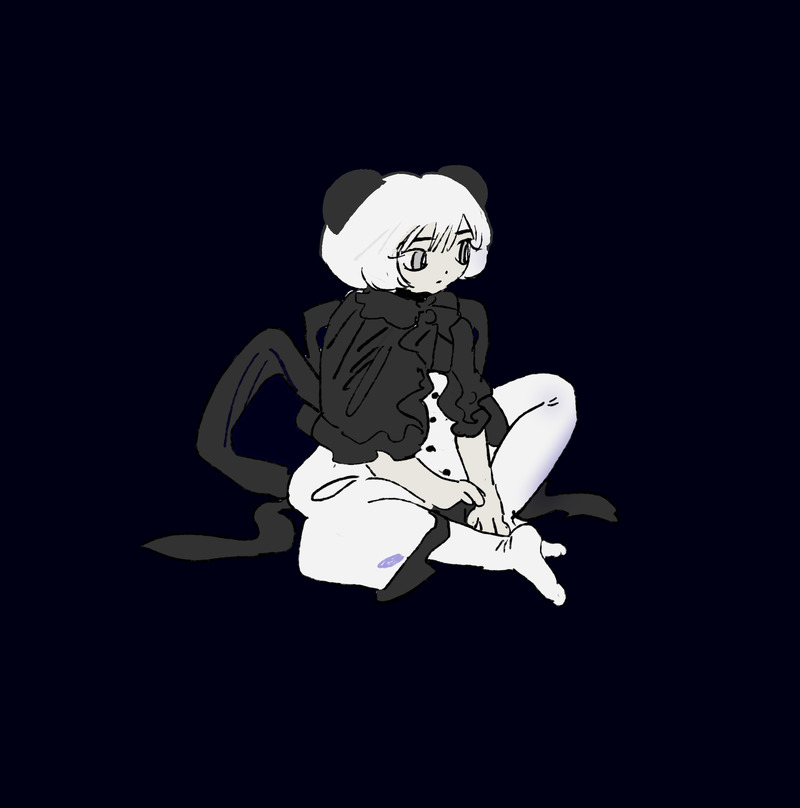

이미지가 중간에 있다면 실제 중간에 있는 이미지를 답변에 삽입해줄 것입니다.


In [10]:
# 입력 마크다운 문자열
md_input = """
# 문서 제목

여기는 첫 번째 문단입니다.
텍스트를 여러 줄 작성할 수 있습니다.

<img src="/content/11.png">

이미지가 중간에 있다면 실제 중간에 있는 이미지를 답변에 삽입해줄 것입니다.
"""

# 이미지 너비를 50px로 지정
display_markdown_with_images(md_input, width=400)